In [27]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Literal
import random

In [28]:
class State(TypedDict):
    play_ground: str

In [29]:
def start_game(state: State):
    return {"playground": state["play_ground"] + " Ready to play"}

def Tenis(state: State):
    return {"play_ground": state["play_ground"] + " Tenis initiated"}

def Football(state: State):
    return {"play_ground": state["play_ground"] + "Football initiated"}

def random_state(state: State) -> Literal["Tenis", "Football"]:
    rand = random.random()
    if rand > 0.5:
        return "Tenis"
    else:
        return "Football"

In [30]:
state_graph = StateGraph(State)

#build graph
state_graph.add_node("start_game", start_game)
state_graph.add_node("Tenis", Tenis)
state_graph.add_node("Football", Football)

#schedule flow
state_graph.add_edge(START, "start_game")
state_graph.add_conditional_edges("start_game", random_state)
state_graph.add_edge("Tenis", END)
state_graph.add_edge("Football", END)

state_graph_builder = state_graph.compile()

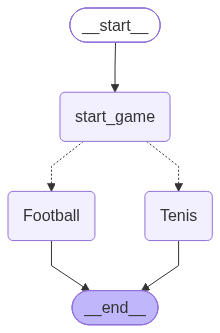

In [31]:
from IPython.display import Image,display
## View
display(Image(state_graph_builder.get_graph().draw_mermaid_png()))

In [32]:
state_graph_builder.invoke({"play_ground": "Hey"})

{'play_ground': 'Hey Tenis initiated'}

#### Chatbot

In [35]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [37]:
from langchain_openai import AzureChatOpenAI
client = AzureChatOpenAI(
    api_key = os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
    azure_deployment = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    azure_endpoint= os.getenv("AZURE_OPENAI_ENDPOINT"),
)

In [38]:
from typing import Annotated
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]

In [39]:
def superbot(state: State):
    return {"messages": [client.invoke(state["messages"])]}

In [40]:
graph = StateGraph(State)

graph.add_node("superbot", superbot)

graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile()

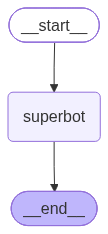

In [41]:
## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))